Файл успешно загружен и сохранён как 'insurance.csv'.
Общая информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1244 entries, 0 to 1243
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1244 non-null   int64  
 1   sex       1244 non-null   object 
 2   bmi       1244 non-null   float64
 3   children  1244 non-null   int64  
 4   smoker    1244 non-null   object 
 5   region    1244 non-null   object 
 6   charges   1244 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 68.2+ KB
None

Пропуски в данных:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Основные статистики:
                age          bmi     children       charges
count  1244.000000  1244.000000  1244.000000   1244.000000
mean     39.088424    30.582858     1.103698  13198.216342
std      14.055295     6.159513     1.215885  12001.805804
min

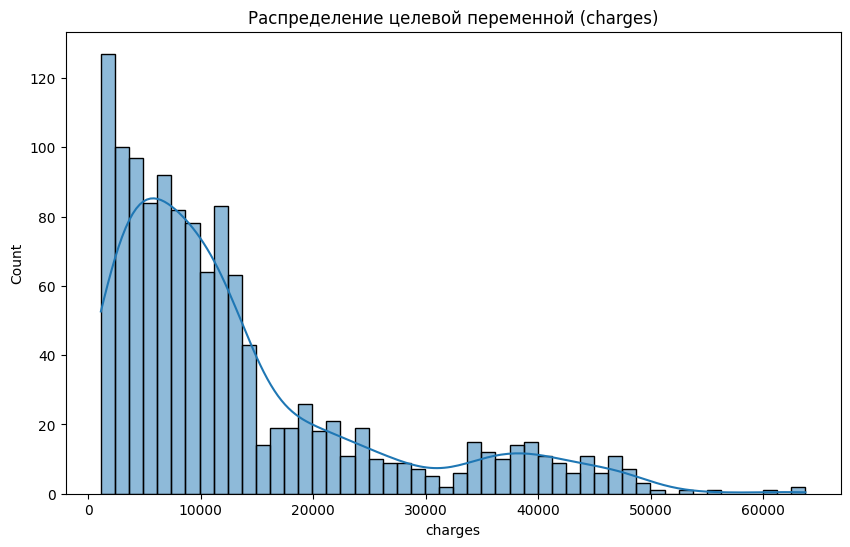

Обработанные данные (первые строки):
    age     bmi  children      charges  sex_male  smoker_yes  region_northwest  \
0   19  27.900         0  16884.92400     False        True             False   
1   18  33.770         1   1725.55230      True       False             False   
2   28  33.000         3   4449.46200      True       False             False   
3   33  22.705         0  21984.47061      True       False              True   
4   32  28.880         0   3866.85520      True       False              True   

   region_southeast  region_southwest  
0             False              True  
1              True             False  
2              True             False  
3             False             False  
4             False             False  


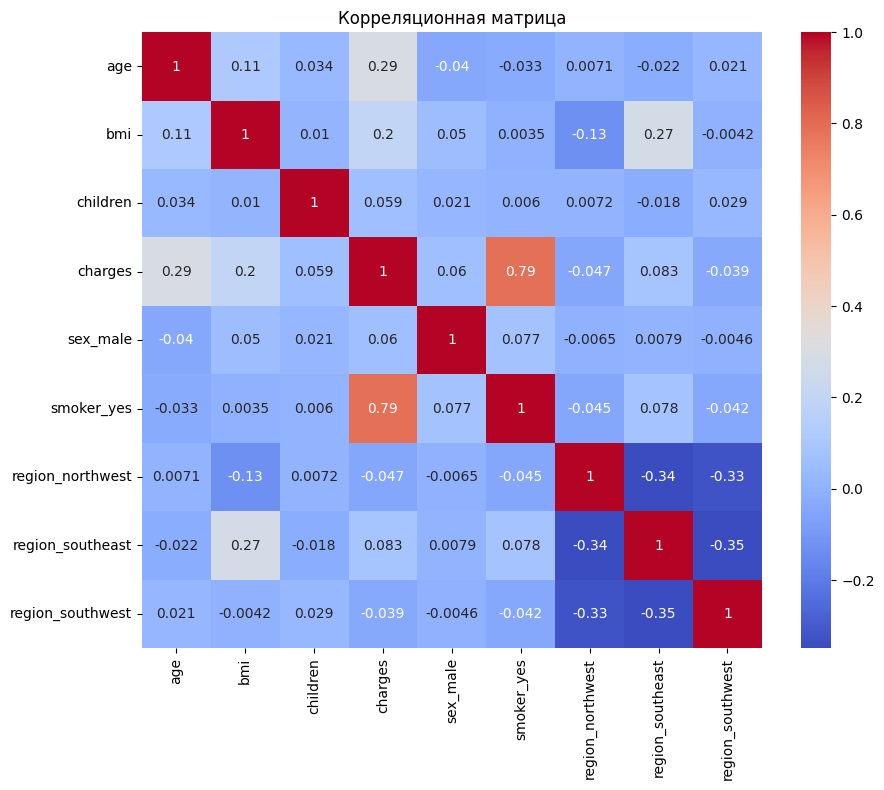

Размерность признаков X: (1244, 8)
Размерность целевой переменной y: (1244,)


In [2]:
import requests
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


url = "https://github.com/LlirikOknessu/tpu-8e22-ML-course/raw/refs/heads/Demonstration/Kulakov/data/raw/insurance.csv"


response = requests.get(url)


if response.status_code == 200:
    with open("insurance.csv", "wb") as file:
        file.write(response.content)
    print("Файл успешно загружен и сохранён как 'insurance.csv'.")
else:
    print(f"Ошибка загрузки файла: {response.status_code}")
    exit()


data = pd.read_csv("insurance.csv")


print("Общая информация о данных:")
print(data.info())
print("\nПропуски в данных:\n", data.isnull().sum())
print("\nОсновные статистики:\n", data.describe())


plt.figure(figsize=(10, 6))
sns.histplot(data['charges'], bins=50, kde=True)
plt.title("Распределение целевой переменной (charges)")
plt.show()


data = pd.get_dummies(data, columns=['sex', 'smoker', 'region'], drop_first=True)


print("Обработанные данные (первые строки):\n", data.head())


plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.title("Корреляционная матрица")
plt.show()


X = data.drop(columns=['charges'])  
y = data['charges']  


print(f"Размерность признаков X: {X.shape}")
print(f"Размерность целевой переменной y: {y.shape}")

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


def build_pipeline(model):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


lin_reg = build_pipeline(LinearRegression())
lin_reg.fit(X, y)


y_pred_lr = lin_reg.predict(X)


mse_lr = mean_squared_error(y, y_pred_lr)
r2_lr = r2_score(y, y_pred_lr)
print(f"Линейная регрессия: MSE = {mse_lr}, R2 = {r2_lr}")

Линейная регрессия: MSE = 35982623.35333798, R2 = 0.7499948909712617


Дерево решений: MSE = 19192040.481983922, R2 = 0.8666548537590925


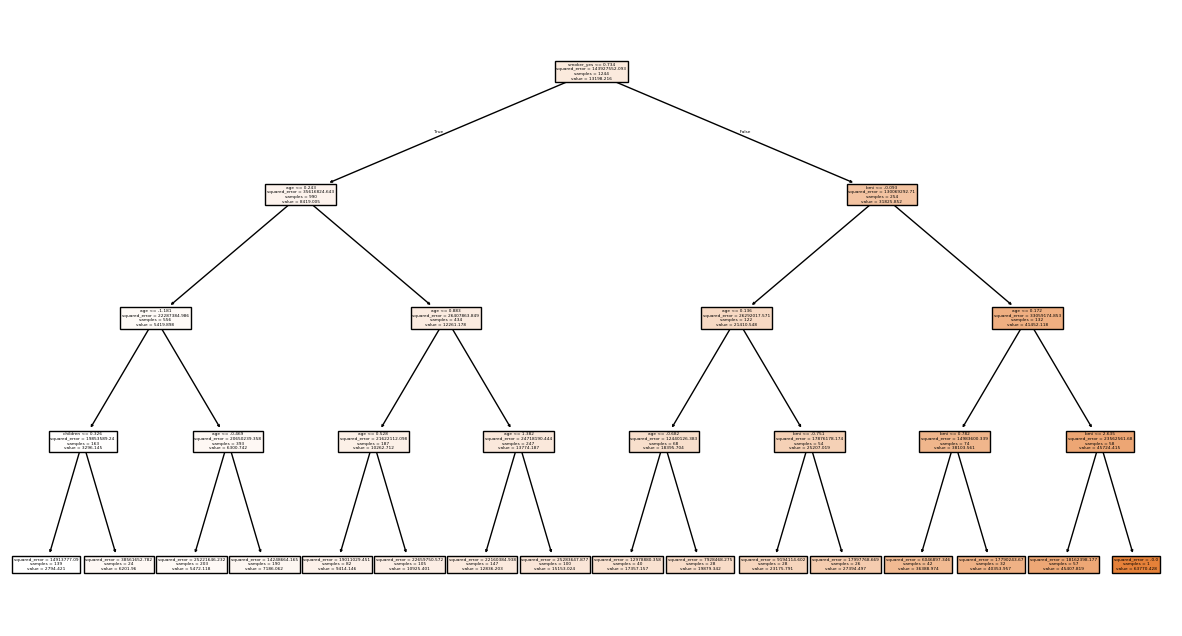

In [5]:
from sklearn.tree import DecisionTreeRegressor, plot_tree


tree = build_pipeline(DecisionTreeRegressor(max_depth=4, random_state=42))
tree.fit(X, y)


y_pred_tree = tree.predict(X)


mse_tree = mean_squared_error(y, y_pred_tree)
r2_tree = r2_score(y, y_pred_tree)
print(f"Дерево решений: MSE = {mse_tree}, R2 = {r2_tree}")


plt.figure(figsize=(15, 8))
plot_tree(tree.named_steps["model"], feature_names=X.columns, filled=True)
plt.show()

In [6]:
from catboost import CatBoostRegressor


catboost = CatBoostRegressor(verbose=0, random_state=42)
catboost.fit(X, y)


y_pred_cb = catboost.predict(X)


mse_cb = mean_squared_error(y, y_pred_cb)
r2_cb = r2_score(y, y_pred_cb)
print(f"CatBoost: MSE = {mse_cb}, R2 = {r2_cb}")


feature_importances = catboost.get_feature_importance(prettified=True)
print("Feature Importance:\n", feature_importances)

CatBoost: MSE = 7663794.903388277, R2 = 0.9467524126414831
Feature Importance:
          Feature Id  Importances
0        smoker_yes    70.546152
1               bmi    14.327843
2               age    10.003723
3          children     2.576950
4  region_northwest     0.876233
5  region_southwest     0.643260
6          sex_male     0.537024
7  region_southeast     0.488814


Epoch 1/50


/Users/vladimirkulakov/PycharmProjects/tpu-8e22-ML-course/venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 337720672.0000 - mae: 13769.7949 - val_loss: 320836640.0000 - val_mae: 13058.8633
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 338834592.0000 - mae: 13575.5615 - val_loss: 320733536.0000 - val_mae: 13055.4072
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 304152576.0000 - mae: 12884.8857 - val_loss: 320523264.0000 - val_mae: 13048.6729
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 337878080.0000 - mae: 13749.1230 - val_loss: 320114816.0000 - val_mae: 13036.2471
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 304290464.0000 - mae: 12863.4893 - val_loss: 319395456.0000 - val_mae: 13015.3818
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 314797184.0000 - mae: 13062.8516 - val_loss: 318255904.0000 - val_mae: 12983.5293
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 312917472.0000 - mae: 12954.5166 - val_loss: 316593248.0000 - val_mae: 12938.2803
Epoch 8/50
32/32 ━━━━━━━━━━━━━━

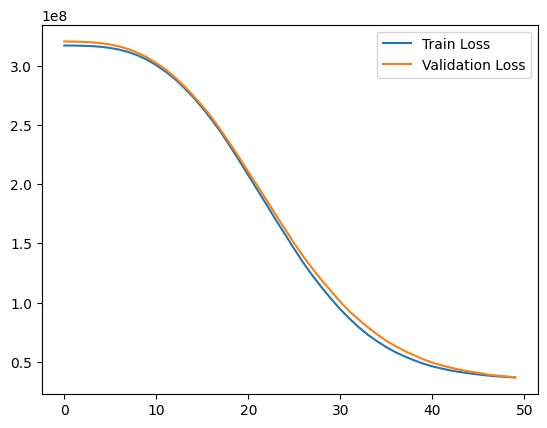

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import TensorBoard


model = Sequential([
    Dense(64, input_dim=X.shape[1], activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])
model.compile(optimizer='adam', loss='mse', metrics=['mae'])


history = model.fit(X_scaled, y, validation_split=0.2, epochs=50, verbose=1)


plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()